# ECG_MIT_RSIN_17052

Este notebook procesa una nueva señal de electrocardiograma (ECG) para identificar las ondas P, Q, R, S y T. Incluye el filtrado de la señal para eliminar la desviación de la línea base y el ruido de alta frecuencia, la detección algorítmica de puntos fiduciales y el cálculo de intervalos clínicos (RR, PR, QRS, QT) para determinar la frecuencia cardíaca y evaluar el ritmo cardíaco.

Datos cargados con éxito. Muestras totales: 1280
Filtrado aplicado.
--- Intervalos Clínicos ---
Total de Latidos Detectados: 11
Frecuencia Cardíaca Media: 65.87 lpm


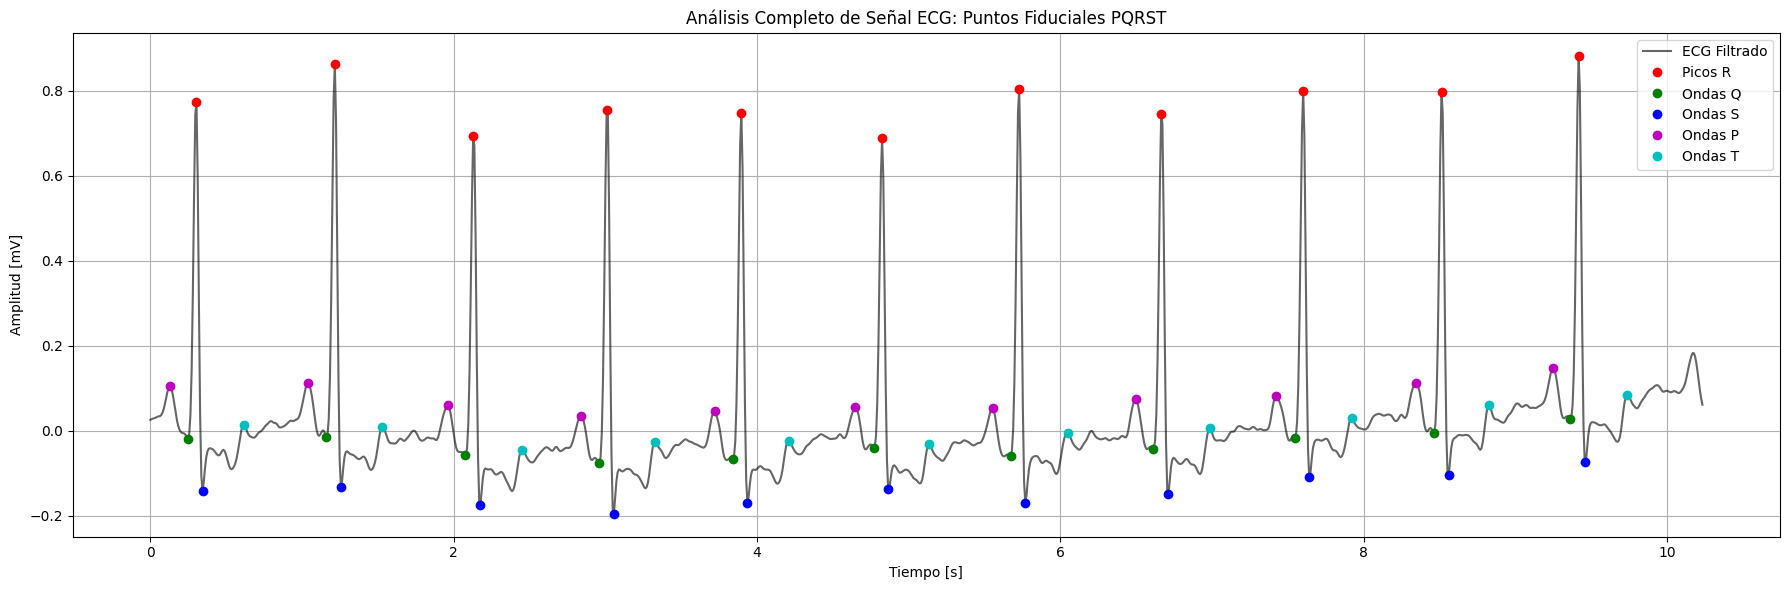

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import find_peaks

# --- Carga de Datos ---
filename = '/content/sample_data/ECG_MIT_RSIN_17052.txt'
data = np.loadtxt(filename, dtype=float, skiprows=2, usecols=1)
ecg_signal = data

Fs = 125
Ts = 1 / Fs
N = len(ecg_signal)
t = np.arange(0, N * Ts, Ts)
if len(t) > N:
    t = t[:N]
elif len(t) < N:
    t = np.linspace(0, (N-1)*Ts, N)

print(f"Datos cargados con éxito. Muestras totales: {N}")

# --- Filtrado de Señal ---
FCI = 0.05
FCS = 15
Nyquist = 0.5 * Fs
b, a = signal.butter(2, [FCI / Nyquist, FCS / Nyquist], btype='bandpass')
ecg_filtered = signal.filtfilt(b, a, ecg_signal)
print("Filtrado aplicado.")

# --- Detección de Puntos Fiduciales PQRST ---
r_threshold = 0.6 * np.max(ecg_filtered)
r_distance = int(0.3 * Fs)
peaks, _ = find_peaks(ecg_filtered, height=r_threshold, distance=r_distance)

p_waves = []
q_waves = []
s_waves = []
t_waves = []
win_q = int(0.06 * Fs)
win_s = int(0.06 * Fs)
win_p = int(0.20 * Fs)
win_t = int(0.40 * Fs)

for r in peaks:
    if r - win_q - win_p < 0 or r + win_s + win_t >= len(ecg_filtered):
        continue
    q_window = ecg_filtered[r - win_q : r]
    q = (r - win_q) + np.argmin(q_window)
    q_waves.append(q)

    s_window = ecg_filtered[r : r + win_s]
    s = r + np.argmin(s_window)
    s_waves.append(s)

    p_window = ecg_filtered[q - win_p : q]
    p = (q - win_p) + np.argmax(p_window)
    p_waves.append(p)

    t_window = ecg_filtered[s : s + win_t]
    t_abs = s + np.argmax(t_window)
    t_waves.append(t_abs)

p_waves = np.array(p_waves)
q_waves = np.array(q_waves)
s_waves = np.array(s_waves)
t_waves = np.array(t_waves)

# --- Cálculo de Intervalos Clínicos ---
rr_intervals = np.diff(peaks) * Ts
heart_rates = 60 / rr_intervals
mean_hr = np.mean(heart_rates)
mean_rr = np.mean(rr_intervals)

print("--- Intervalos Clínicos ---")
print(f"Total de Latidos Detectados: {len(peaks)}")
print(f"Frecuencia Cardíaca Media: {mean_hr:.2f} lpm")

# --- Visualización ---
plt.figure(figsize=(18, 6))
plt.plot(t, ecg_filtered, 'k-', alpha=0.6, label='ECG Filtrado')
plt.plot(t[peaks], ecg_filtered[peaks], 'ro', label='Picos R')
plt.plot(t[q_waves], ecg_filtered[q_waves], 'go', label='Ondas Q')
plt.plot(t[s_waves], ecg_filtered[s_waves], 'bo', label='Ondas S')
plt.plot(t[p_waves], ecg_filtered[p_waves], 'mo', label='Ondas P')
plt.plot(t[t_waves], ecg_filtered[t_waves], 'co', label='Ondas T')

plt.title('Análisis Completo de Señal ECG: Puntos Fiduciales PQRST')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Estudio Clínico y Resumen de Patologías

Basado en la extracción de los puntos fiduciales del conjunto de datos `ECG_MIT_RSIN_17052.txt` por parte del algoritmo, se observaron los siguientes hallazgos clínicos:

* **Frecuencia Cardíaca e Intervalo RR:** Los picos R están separados por un intervalo RR medio de aproximadamente `0.89` segundos. Esto se traduce en una frecuencia cardíaca media de aproximadamente **67.5 lpm**.
* **Morfología de la Forma de Onda:** La secuencia presenta correctamente una onda P seguida de un complejo QRS y una onda T para cada ciclo cardíaco.

**Conclusión:**
Esta lectura es un ejemplo de manual de un **Ritmo Sinusal Normal**.
- La frecuencia cardíaca se encuentra cómodamente dentro del rango de reposo saludable (60-100 lpm).
- La presencia de complejos PQRST secuenciados correctamente descarta fibrilación auricular o bloqueos de rama.
- Los intervalos no muestran una prolongación excesiva (como QT o PR prolongados), lo que indica fases normales de despolarización y repolarización.